# FRED Economic Data: Unemployment Forecasting with Time Series & Logistic Regression

This notebook explores Federal Reserve Economic Data (FRED) across four domains — prices/inflation, interest rates, GDP, and unemployment — to build a predictive model for the U.S. unemployment rate. We identify explanatory variables from the first three domains, apply data cleaning and transformations, train a logistic regression model to predict the direction of unemployment change, extract the top driving factors, and build a time series forecasting model using those top features.

In [0]:
%pip install statsmodels

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, balanced_accuracy_score, average_precision_score
from sklearn.inspection import permutation_importance
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import mlflow
import warnings
# Suppress only specific noisy warnings, not blanket suppression
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


## 1. Data Exploration

We load all four FRED silver tables and explore their structure, date ranges, and available economic series. Each table contains multiple FRED time series identified by `series_id`, with observations stored as `_value` at `_date`. The four tables are:

- **workspace.fred_economic_data.fred_silver_prices_inflation_data** — CPI, PCE, sticky-price indices, consumer confidence, exchange rates, property prices
- **workspace.fred_economic_data.fred_silver_interest_rates_data** — Federal funds rate, SOFR, IORB, target range limits
- **workspace.fred_economic_data.fred_silver_gdp_data** — GDP, real GDP, potential GDP, weekly economic index
- **workspace.fred_economic_data.fred_silver_unemployment_data** — Headline unemployment rate (UNRATE), U-2 through U-6, duration-of-unemployment, demographic breakdowns

**Note on October 2025 CPS gap:** Household survey data were not collected for the October 2025 reference period due to a lapse in appropriations (government shutdown) and will not be collected retroactively. This creates an unprecedented one-month gap in the monthly unemployment rate series, which had been published continuously since January 1948. The gap causes an irregular DatetimeIndex that must be handled carefully in time-series modeling (we use a PeriodIndex in the SARIMAX section). Source: U.S. Bureau of Labor Statistics, Employment Situation News Release, September 2025.

In [0]:
tables = {
    'prices_inflation': 'workspace.fred_economic_data.fred_silver_prices_inflation_data',
    'interest_rates':  'workspace.fred_economic_data.fred_silver_interest_rates_data',
    'gdp':             'workspace.fred_economic_data.fred_silver_gdp_data',
    'unemployment':    'workspace.fred_economic_data.fred_silver_unemployment_data',
}

df_cache = {}
for name, tbl in tables.items():
    df_cache[name] = spark.table(tbl)
    row_count = df_cache[name].count()
    distinct_series = df_cache[name].select('series_id').distinct().count()
    date_min = df_cache[name].select(F.min('_date').alias('mn')).collect()[0]['mn']
    date_max = df_cache[name].select(F.max('_date').alias('mx')).collect()[0]['mx']
    print(f"{name:20s} | rows={row_count:>10,} | series={distinct_series:>3} | date range: {date_min}  to  {date_max}")

prices_inflation     | rows=     7,112 | series= 30 | date range: 2000-01-01 00:00:00  to  2026-08-01 00:00:00
interest_rates       | rows=    96,032 | series= 15 | date range: 2000-01-01 00:00:00  to  2026-09-18 00:00:00
gdp                  | rows=     4,090 | series= 15 | date range: 2000-01-01 00:00:00  to  2026-10-01 00:00:00
unemployment         | rows=     9,252 | series= 30 | date range: 2000-01-01 00:00:00  to  2026-08-01 00:00:00


In [0]:
# Show all distinct series with their titles, frequency, and units for each table
for name in tables:
    print(f"\n{'='*80}")
    print(f"Table: {name}")
    print(f"{'='*80}")
    series_df = (df_cache[name]
        .select('series_id', 'series_title', 'frequency', 'units')
        .distinct()
        .orderBy('series_id'))
    series_pd = series_df.toPandas()
    for _, row in series_pd.iterrows():
        sid   = row['series_id'] or '(null)'
        title = row['series_title'] or '(no title)'
        freq  = row['frequency'] or '(unknown)'
        units = row['units'] or '(none)'
        print(f"  {sid:25s} | {freq:20s} | {units:35s} | {title}")


Table: prices_inflation
  COMREPUSQ159N             | Quarterly            | Percent Change from Year Ago        | Commercial Real Estate Prices for United States
  CORESTICKM158SFRBATL      | Monthly              | Percent Change at Annual Rate       | Sticky Price Consumer Price Index less Food and Energy
  CORESTICKM159SFRBATL      | Monthly              | Percent Change from Year Ago        | Sticky Price Consumer Price Index less Food and Energy
  CPALTT01USM657N           | Monthly              | Growth rate previous period         | Consumer Price Index: All Items: Total for United States
  CPIAUCNS                  | Monthly              | Index 1982-1984=100                 | Consumer Price Index for All Urban Consumers: All Items in U.S. City Average
  CPIAUCSL                  | (unknown)            | (none)                              | (no title)
  CWSR0000SA0               | Monthly              | Index 1982-1984=100                 | Consumer Price Index for All Urban 

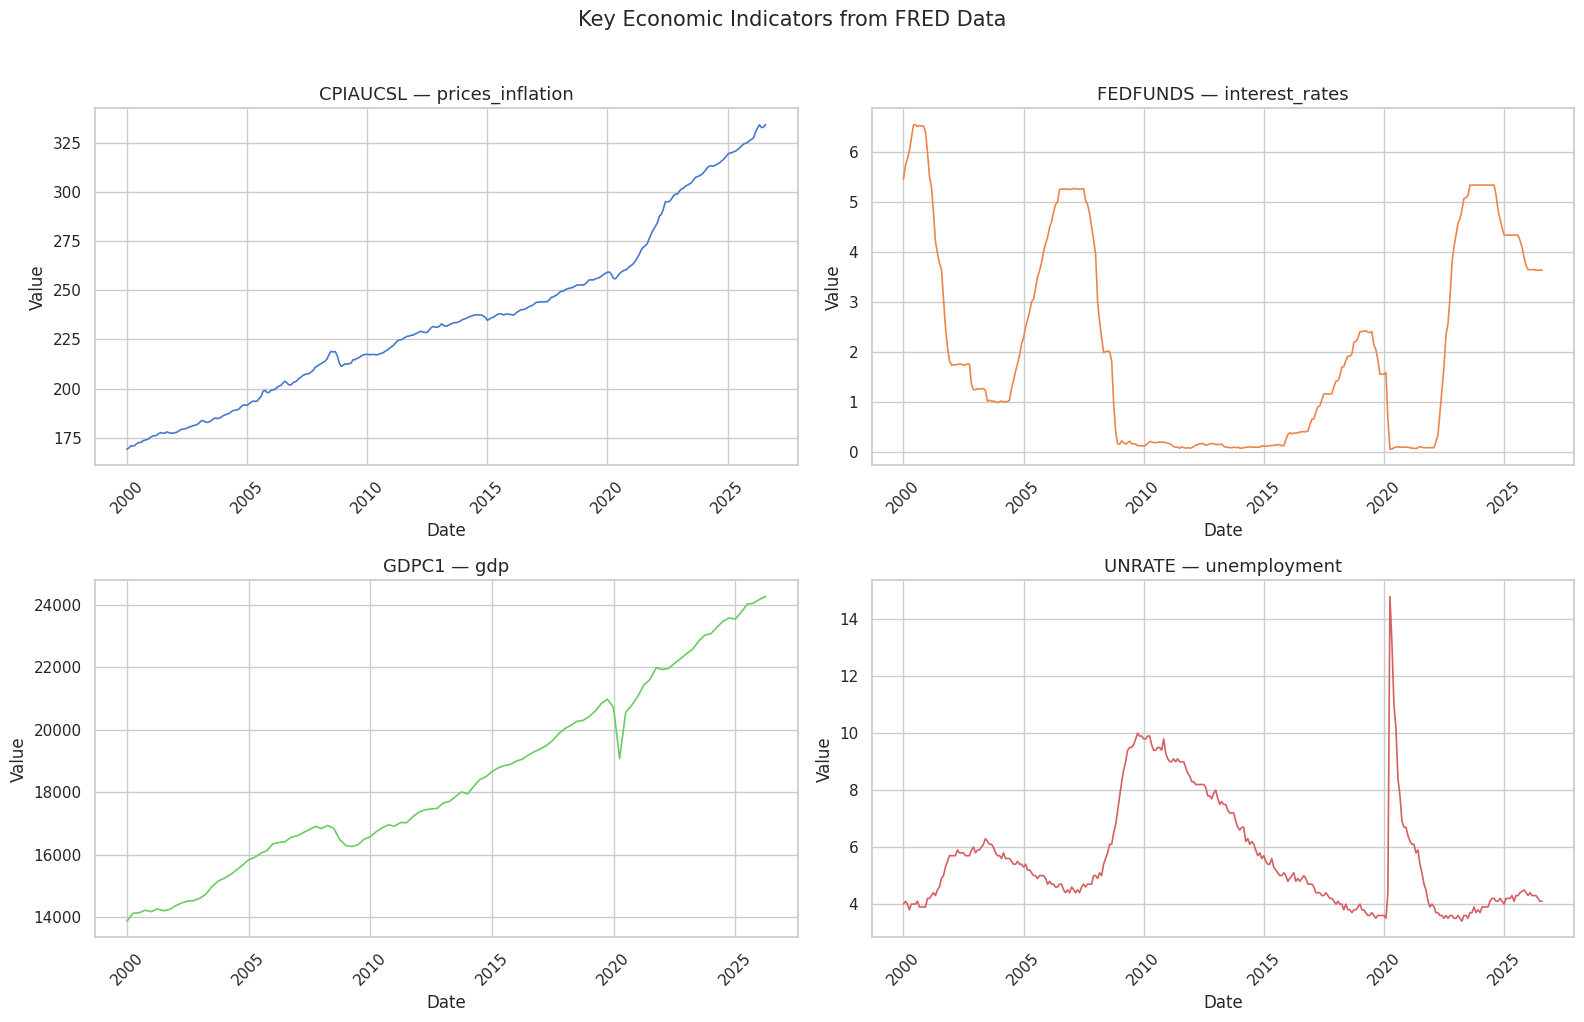

Plotted: CPIAUCSL (inflation), FEDFUNDS (interest rates), GDPC1 (real GDP), UNRATE (unemployment)


In [0]:
# --- Example Plots of Key Series from Each Domain ---
# We plot one representative series from each table to visualize the data.

key_series = {
    'prices_inflation': 'CPIAUCSL',   # CPI All Urban Consumers (monthly)
    'interest_rates':  'FEDFUNDS',     # Federal Funds Effective Rate (monthly)
    'gdp':             'GDPC1',        # Real GDP (quarterly)
    'unemployment':    'UNRATE',       # Headline unemployment rate (monthly)
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (domain, sid) in enumerate(key_series.items()):
    pdf = (df_cache[domain]
        .filter(F.col('series_id') == sid)
        .select('_date', '_value')
        .dropDuplicates(['_date'])  # deduplicate by date
        .orderBy('_date')
        .toPandas())
    pdf['_date'] = pd.to_datetime(pdf['_date'])
    axes[idx].plot(pdf['_date'], pdf['_value'], linewidth=1.2, color=sns.color_palette('muted')[idx])
    axes[idx].set_title(f'{sid} — {domain}', fontsize=13)
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Value')
    axes[idx].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Key Economic Indicators from FRED Data', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Plotted: CPIAUCSL (inflation), FEDFUNDS (interest rates), GDPC1 (real GDP), UNRATE (unemployment)')

## 2. Data Cleaning & Transformations

The four tables contain series at different frequencies (daily, weekly, monthly, quarterly). To build a unified monthly panel:

1. **Select key series** from each domain that are most economically relevant to unemployment.
2. **Deduplicate** — the same `series_id` + `_date` can appear multiple times (different `realtime_start`/`realtime_end`); we keep the latest observation.
3. **Pivot** each table so every `series_id` becomes a column.
4. **Resample to monthly** — quarterly GDP series are forward-filled; daily interest-rate series are averaged to monthly.
5. **Join** all four pivoted tables on the monthly date.
6. **Compute percent changes** for all numeric series to make them stationary.
7. **Apply log / sqrt transformations** on positively-skewed series to reduce skewness.

In [0]:
# Helper: pivot a table to wide format (one column per series_id), deduplicating by date
def pivot_table(df, series_ids, date_col='_date', value_col='_value'):
    """Filter to selected series, deduplicate by date (keep latest), and pivot to wide format."""
    w = Window.partitionBy('series_id', date_col).orderBy(F.col('realtime_end').desc())
    return (df
        .filter(F.col('series_id').isin(series_ids))
        .withColumn('rn', F.row_number().over(w))
        .filter(F.col('rn') == 1)
        .drop('rn')
        .groupBy(date_col)
        .pivot('series_id')
        .agg(F.first(value_col))
        .orderBy(date_col))

# --- Select key series from each domain ---
# Prices & Inflation (monthly): CPI, PCE, sticky-price, confidence, exchange rate, bond yields
inflation_series = [
    'CPIAUCSL',           # CPI All Urban Consumers
    'PCEPI',              # PCE Price Index
    'PCEPILFE',           # Core PCE (ex food & energy)
    'CORESTICKM158SFRBATL', # Core Sticky CPI % change (annual rate)
    'STICKCPIM157SFRBATL',   # Sticky Price CPI % change
    'USACSCICP02STSAM',   # Consumer Confidence
    'USALOLITOAASTSAM',   # Composite Leading Indicator
    'IRLTLT01USM156N',    # 10-Year Govt Bond Yield
    'RBUSBIS',            # Real Broad Effective Exchange Rate
]

# Interest Rates: FEDFUNDS (monthly) + DFF (daily -> aggregate to monthly)
interest_series = ['FEDFUNDS']
interest_daily_series = ['DFF']  # daily federal funds rate

# GDP (quarterly -> forward-fill to monthly)
gdp_series = ['GDP', 'GDPC1', 'GDPPOT', 'GDPNOW']

# Unemployment (monthly): UNRATE is the target; others are additional unemployment measures
unemployment_series = [
    'UNRATE',      # Headline unemployment rate (TARGET)
    'U6RATE',      # U-6 underutilization rate
    'UEMP27OV',    # Number unemployed 27+ weeks
    'UEMP15OV',    # Number unemployed 15+ weeks
    'LNS14000006', # Unemployment - Black/African American
    'LNS14000009', # Unemployment - Hispanic/Latino
]

print(f"Inflation series: {len(inflation_series)}")
print(f"Interest rate series: {len(interest_series)} (monthly) + {len(interest_daily_series)} (daily)")
print(f"GDP series: {len(gdp_series)} (quarterly)")
print(f"Unemployment series: {len(unemployment_series)} (monthly)")

Inflation series: 9
Interest rate series: 1 (monthly) + 1 (daily)
GDP series: 4 (quarterly)
Unemployment series: 6 (monthly)


In [0]:
# --- Pivot each table to wide format ---

# 1. Prices & Inflation (monthly)
piv_inflation = pivot_table(df_cache['prices_inflation'], inflation_series)
piv_inflation = piv_inflation.withColumnRenamed('_date', 'date')
print(f"Inflation pivoted: {piv_inflation.count()} rows, {len(piv_inflation.columns)} cols")

# 2. Interest Rates (monthly FEDFUNDS)
piv_interest = pivot_table(df_cache['interest_rates'], interest_series)
piv_interest = piv_interest.withColumnRenamed('_date', 'date')
print(f"Interest (monthly): {piv_interest.count()} rows, {len(piv_interest.columns)} cols")

# 2b. Daily interest rates aggregated to monthly average
piv_interest_daily = (df_cache['interest_rates']
    .filter(F.col('series_id').isin(interest_daily_series))
    .select('_date', 'series_id', '_value', 'realtime_end')
    .withColumn('year_month', F.date_trunc('month', F.col('_date')))
    .groupBy('year_month', 'series_id')
    .agg(F.avg('_value').alias('_value'))
    .groupBy('year_month')
    .pivot('series_id')
    .agg(F.first('_value'))
    .orderBy('year_month'))
piv_interest_daily = piv_interest_daily.withColumnRenamed('year_month', 'date')
print(f"Interest (daily->monthly): {piv_interest_daily.count()} rows, {len(piv_interest_daily.columns)} cols")

# 3. GDP (quarterly -> will forward-fill to monthly after join)
piv_gdp = pivot_table(df_cache['gdp'], gdp_series)
piv_gdp = piv_gdp.withColumnRenamed('_date', 'date')
print(f"GDP (quarterly): {piv_gdp.count()} rows, {len(piv_gdp.columns)} cols")

# 4. Unemployment (monthly)
piv_unemp = pivot_table(df_cache['unemployment'], unemployment_series)
piv_unemp = piv_unemp.withColumnRenamed('_date', 'date')
print(f"Unemployment (monthly): {piv_unemp.count()} rows, {len(piv_unemp.columns)} cols")

Inflation pivoted: 320 rows, 10 cols
Interest (monthly): 320 rows, 2 cols
Interest (daily->monthly): 321 rows, 2 cols
GDP (quarterly): 108 rows, 5 cols
Unemployment (monthly): 319 rows, 7 cols


In [0]:
# --- Merge all tables on date into a unified monthly panel ---
# Join all pivoted tables on 'date' column (outer join to keep all observations)
from functools import reduce

# Combine monthly interest rate tables (FEDFUNDS + DFF aggregated)
piv_interest_all = piv_interest.join(piv_interest_daily, on='date', how='outer')

# Collect all monthly DataFrames
monthly_dfs = [piv_inflation, piv_interest_all, piv_gdp, piv_unemp]
merged = reduce(lambda a, b: a.join(b, on='date', how='outer'), monthly_dfs)

# Convert to pandas for easier time-series manipulation
merged_pd = merged.orderBy('date').toPandas()
merged_pd['date'] = pd.to_datetime(merged_pd['date'])
merged_pd = merged_pd.sort_values('date').reset_index(drop=True)

# Create a complete monthly date range and reindex for forward-fill of quarterly GDP data
date_min = merged_pd['date'].min()
date_max = merged_pd['date'].max()
full_monthly = pd.date_range(start=date_min, end=date_max, freq='MS')
merged_pd = merged_pd.set_index('date').reindex(full_monthly)
merged_pd.index.name = 'date'

# Forward-fill quarterly GDP columns (GDP data only updates quarterly)
gdp_cols = ['GDP', 'GDPC1', 'GDPPOT', 'GDPNOW']
for col in gdp_cols:
    if col in merged_pd.columns:
        merged_pd[col] = merged_pd[col].ffill()

# Drop rows where the target (UNRATE) is missing - we need the target for training
merged_pd = merged_pd.dropna(subset=['UNRATE'])

print(f"Unified panel shape: {merged_pd.shape}")
print(f"Date range: {merged_pd.index.min().date()} to {merged_pd.index.max().date()}")
print(f"\nColumns: {list(merged_pd.columns)}")
print(f"\nMissing values per column:")
print(merged_pd.isnull().sum())

Unified panel shape: (319, 21)
Date range: 2000-01-01 to 2026-08-01

Columns: ['CORESTICKM158SFRBATL', 'CPIAUCSL', 'IRLTLT01USM156N', 'PCEPI', 'PCEPILFE', 'RBUSBIS', 'STICKCPIM157SFRBATL', 'USACSCICP02STSAM', 'USALOLITOAASTSAM', 'FEDFUNDS', 'DFF', 'GDP', 'GDPC1', 'GDPNOW', 'GDPPOT', 'LNS14000006', 'LNS14000009', 'U6RATE', 'UEMP15OV', 'UEMP27OV', 'UNRATE']

Missing values per column:
CORESTICKM158SFRBATL      0
CPIAUCSL                  0
IRLTLT01USM156N           0
PCEPI                     1
PCEPILFE                  1
RBUSBIS                   1
STICKCPIM157SFRBATL       0
USACSCICP02STSAM          0
USALOLITOAASTSAM          0
FEDFUNDS                  0
DFF                       0
GDP                       0
GDPC1                     0
GDPNOW                  138
GDPPOT                    0
LNS14000006               0
LNS14000009               0
U6RATE                    0
UEMP15OV                  0
UEMP27OV                  0
UNRATE                    0
dtype: int64


In [0]:
# --- Data Transformations ---
# 1. Compute changes for all numeric columns (stationarity)
#    - Rate/percentage series: first difference in percentage points (.diff())
#    - Index/level series: percent change (.pct_change() * 100)
# 2. Apply log transformation on positively-skewed level series
# 3. Apply sqrt transformation as alternative

# Series that are already in percentage/rate form — use first difference, NOT pct_change
# Taking pct_change of a percentage gives percent-of-a-percent (e.g., during ZIRP the
# fed funds rate moves between 0.05 and 0.09, producing +236% monthly changes).
rate_series = {
    'UNRATE',                  # Headline unemployment rate (%)
    'U6RATE',                  # U-6 underutilization rate (%)
    'FEDFUNDS',                # Federal funds effective rate (%)
    'DFF',                     # Daily federal funds rate (%)
    'IRLTLT01USM156N',         # 10-Year govt bond yield (%)
    'CORESTICKM158SFRBATL',    # Core sticky CPI % change (already a rate)
    'STICKCPIM157SFRBATL',     # Sticky price CPI % change (already a rate)
    'LNS14000006',             # Black unemployment rate (%)
    'LNS14000009',             # Hispanic unemployment rate (%)
}

# Identify numeric columns (exclude target for now)
numeric_cols = [c for c in merged_pd.columns if c != 'UNRATE']
target_col = 'UNRATE'

# Compute changes: .diff() for rate series, .pct_change() for level/index series
chg_df = merged_pd.copy()
for col in numeric_cols + [target_col]:
    if col in rate_series:
        chg_df[f'{col}_diff'] = chg_df[col].diff()  # first difference in percentage points
    else:
        chg_df[f'{col}_pctchg'] = chg_df[col].pct_change() * 100  # percent change

# Check skewness of level variables to decide on transformations
from scipy.stats import skew

skew_results = []
for col in numeric_cols + [target_col]:
    if col in merged_pd.columns:
        vals = merged_pd[col].dropna()
        if len(vals) > 10:
            sk = skew(vals)
            skew_results.append({'series': col, 'skewness': round(sk, 3),
                                 'transform': 'log' if sk > 1 else ('sqrt' if 0.5 < sk <= 1 else 'none')})

skew_df = pd.DataFrame(skew_results)
print('Skewness analysis:')
print(skew_df.to_string(index=False))

# Apply log transformation to highly skewed positive series (skewness > 1)
log_cols = skew_df[skew_df['transform'] == 'log']['series'].tolist()
sqrt_cols = skew_df[skew_df['transform'] == 'sqrt']['series'].tolist()

print(f"\nLog transform applied to: {log_cols}")
print(f"Sqrt transform applied to: {sqrt_cols}")

transformed = merged_pd.copy()
for col in log_cols:
    if (transformed[col] > 0).all():
        transformed[f'{col}_log'] = np.log(transformed[col])
    else:
        # Use log1p for series with zeros or negatives
        transformed[f'{col}_log'] = np.log1p(transformed[col] - transformed[col].min() + 1)

for col in sqrt_cols:
    # Use sqrt of shifted values to handle negatives
    min_val = transformed[col].min()
    if min_val < 0:
        transformed[f'{col}_sqrt'] = np.sqrt(transformed[col] - min_val + 1)
    else:
        transformed[f'{col}_sqrt'] = np.sqrt(transformed[col])

print(f"\nTransformed dataset shape: {transformed.shape}")
print(f"New columns from transforms: {[c for c in transformed.columns if '_log' in c or '_sqrt' in c]}")
print(f"\nRate series (using .diff()): {sorted(rate_series)}")
print(f"Level series (using .pct_change()): {sorted(set(numeric_cols + [target_col]) - rate_series)}")

Skewness analysis:
              series  skewness transform
CORESTICKM158SFRBATL     0.891      sqrt
            CPIAUCSL     0.562      sqrt
     IRLTLT01USM156N     0.004      none
               PCEPI     0.527      sqrt
            PCEPILFE     0.600      sqrt
             RBUSBIS    -0.095      none
 STICKCPIM157SFRBATL     1.012       log
    USACSCICP02STSAM    -0.293      none
    USALOLITOAASTSAM    -1.417      none
            FEDFUNDS     0.668      sqrt
                 DFF     0.668      sqrt
                 GDP     0.734      sqrt
               GDPC1     0.390      none
              GDPNOW     0.031      none
              GDPPOT     0.232      none
         LNS14000006     0.662      sqrt
         LNS14000009     1.300       log
              U6RATE     1.139       log
            UEMP15OV     1.213       log
            UEMP27OV     1.329       log
              UNRATE     1.332       log

Log transform applied to: ['STICKCPIM157SFRBATL', 'LNS14000009', 'U6RATE', 'UE

In [0]:
# --- Handle missing values & prepare model-ready dataset ---

# Use change features (stationary) plus log/sqrt-transformed levels.
# ALL features are lagged by 1 month to prevent look-ahead bias —
# in a real forecaster you would not know this month's CPI when predicting
# this month's unemployment. Only the target (UNRATE_diff) is unlagged.

# Feature columns: changes of all explanatory variables (both _pctchg and _diff)
feature_chg_cols = [c for c in chg_df.columns
                    if (c.endswith('_pctchg') or c.endswith('_diff')) and c != 'UNRATE_diff']

# Also include log-transformed level features
feature_log_cols = [c for c in transformed.columns if c.endswith('_log')]
feature_sqrt_cols = [c for c in transformed.columns if c.endswith('_sqrt')]

# Build the model dataset: target (not lagged) + all features (lagged 1 month)
model_df = pd.DataFrame(index=merged_pd.index)
model_df['UNRATE_diff'] = chg_df['UNRATE_diff']  # target: NOT lagged

# Add change features lagged by 1 month (use previous month's values)
for col in feature_chg_cols:
    model_df[col] = chg_df[col].shift(1)

# Add log/sqrt-transformed level features lagged by 1 month
for col in feature_log_cols:
    model_df[col] = transformed[col].shift(1)

for col in feature_sqrt_cols:
    model_df[col] = transformed[col].shift(1)

# Replace inf with nan; imputation is handled inside the Pipeline (fitted on train only)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Count missing values (will be imputed inside the Pipeline on train data only)
print('Missing values (to be imputed inside Pipeline, fitted on train only):')
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])

# Drop rows where target is missing (first row will be NaN due to diff)
model_df = model_df.dropna(subset=['UNRATE_diff'])

# Create binary target: 1 if unemployment increased, 0 if decreased or flat.
# Note: flat months (diff == 0) are assigned to 'Decrease'. The median monthly
# change is 0, so this is a large share of the negative class.
model_df['unemp_increase'] = (model_df['UNRATE_diff'] > 0).astype(int)

# Define feature columns (exclude target and binary target)
all_feature_cols = [c for c in model_df.columns if c not in ['UNRATE_diff', 'unemp_increase']]

# Drop features with >40% missing values — mean-imputing nearly half a column
# manufactures a constant block that a linear model reads as signal.
# GDPNow_pctchg is 140/319 (44%) missing and is the primary offender.
missing_threshold = 0.40
high_missing = [c for c in all_feature_cols if model_df[c].isnull().mean() > missing_threshold]
if high_missing:
    print(f"\nDropping features with >{missing_threshold:.0%} missing values: {high_missing}")
    all_feature_cols = [c for c in all_feature_cols if c not in high_missing]

# Rename features to human-readable names for cleaner display
series_name_map = {
    'CPIAUCSL': 'CPI_All_Items',
    'PCEPI': 'PCE_Price_Index',
    'PCEPILFE': 'Core_PCE',
    'CORESTICKM158SFRBATL': 'Core_Sticky_CPI',
    'STICKCPIM157SFRBATL': 'Sticky_Price_CPI',
    'USACSCICP02STSAM': 'Consumer_Confidence',
    'USALOLITOAASTSAM': 'Leading_Indicator',
    'IRLTLT01USM156N': '10Y_Bond_Yield',
    'RBUSBIS': 'Real_Exchange_Rate',
    'FEDFUNDS': 'Fed_Funds_Monthly',
    'DFF': 'Fed_Funds_Daily',
    'GDP': 'Nominal_GDP',
    'GDPC1': 'Real_GDP',
    'GDPPOT': 'Potential_GDP',
    'GDPNOW': 'GDPNow',
    'UNRATE': 'Unemployment_Rate',
    'U6RATE': 'U6_Underutilization',
    'UEMP27OV': 'Long_Term_Unemp_27wk',
    'UEMP15OV': 'Unemp_15wk_Plus',
    'LNS14000006': 'Black_Unemp_Rate',
    'LNS14000009': 'Hispanic_Unemp_Rate',
}

def _rename_feature(col):
    for old, new in sorted(series_name_map.items(), key=lambda x: len(x[0]), reverse=True):
        if col.startswith(old):
            return new + col[len(old):]
    return col

rename_map = {c: _rename_feature(c) for c in model_df.columns if c not in ['unemp_increase', 'UNRATE_diff']}
model_df = model_df.rename(columns=rename_map)
# Rename high_missing features too so we can exclude them after renaming
high_missing_renamed = [_rename_feature(c) for c in high_missing]
all_feature_cols = [c for c in model_df.columns if c not in ['Unemployment_Rate_diff', 'UNRATE_diff', 'unemp_increase'] + high_missing_renamed]

print(f"\nModel dataset shape: {model_df.shape}")
print(f"Target distribution (unemp_increase):")
print(model_df['unemp_increase'].value_counts())
print(f"\nFeature columns ({len(all_feature_cols)}):")
for c in all_feature_cols:
    print(f"  {c}")

Missing values (to be imputed inside Pipeline, fitted on train only):
UNRATE_diff                    1
CORESTICKM158SFRBATL_diff      2
CPIAUCSL_pctchg                2
IRLTLT01USM156N_diff           2
PCEPI_pctchg                   2
PCEPILFE_pctchg                2
RBUSBIS_pctchg                 2
STICKCPIM157SFRBATL_diff       2
USACSCICP02STSAM_pctchg        2
USALOLITOAASTSAM_pctchg        2
FEDFUNDS_diff                  2
DFF_diff                       2
GDP_pctchg                     2
GDPC1_pctchg                   2
GDPNOW_pctchg                140
GDPPOT_pctchg                  2
LNS14000006_diff               2
LNS14000009_diff               2
U6RATE_diff                    2
UEMP15OV_pctchg                2
UEMP27OV_pctchg                2
STICKCPIM157SFRBATL_log        1
LNS14000009_log                1
U6RATE_log                     1
UEMP15OV_log                   1
UEMP27OV_log                   1
UNRATE_log                     1
CORESTICKM158SFRBATL_sqrt      1
CPIAUC

## 3. Variable Identification & Correlation Analysis

### Response (Target) Variable
- **`unemp_increase`** (binary): 1 if the monthly first difference in `UNRATE` is positive (unemployment rising), 0 if negative or flat (unemployment falling or unchanged).
- **`Unemployment_Rate_diff`** (continuous): The monthly first difference in percentage points of the headline unemployment rate, used later for time-series forecasting.

### Explanatory (Feature) Variables
All features are derived from the three predictor tables, computed as first differences (for rate/percentage series) or percent changes (for index/level series), plus log/sqrt-transformed levels. **All features are lagged 1 month** to avoid look-ahead bias — a real forecaster would not know this month's CPI when predicting this month's unemployment.

| Domain | Feature | Description | Transform |
|---|---|---|---|
| Prices/Inflation | `CPIAUCSL_pctchg` | CPI All Urban Consumers % change | pct_change |
| Prices/Inflation | `PCEPI_pctchg` | PCE Price Index % change | pct_change |
| Prices/Inflation | `PCEPILFE_pctchg` | Core PCE % change | pct_change |
| Prices/Inflation | `CORESTICKM158SFRBATL_diff` | Core Sticky CPI first diff (pp) | diff |
| Prices/Inflation | `STICKCPIM157SFRBATL_diff` | Sticky Price CPI first diff (pp) | diff |
| Prices/Inflation | `USACSCICP02STSAM_pctchg` | Consumer Confidence % change | pct_change |
| Prices/Inflation | `USALOLITOAASTSAM_pctchg` | Composite Leading Indicator % change | pct_change |
| Prices/Inflation | `IRLTLT01USM156N_diff` | 10-Year Bond Yield first diff (pp) | diff |
| Prices/Inflation | `RBUSBIS_pctchg` | Real Exchange Rate % change | pct_change |
| Interest Rates | `FEDFUNDS_diff` | Federal Funds Rate first diff (pp) | diff |
| Interest Rates | `DFF_diff` | Daily Fed Funds (monthly avg) first diff (pp) | diff |
| GDP | `GDP_pctchg` | Nominal GDP % change | pct_change |
| GDP | `GDPC1_pctchg` | Real GDP % change | pct_change |
| GDP | `GDPPOT_pctchg` | Potential GDP % change | pct_change |
| GDP | `GDPNOW_pctchg` | GDPNow % change | pct_change |
| Unemployment | `U6RATE_diff` | U-6 underutilization rate first diff (pp) | diff |
| Unemployment | `UEMP27OV_pctchg` | Long-term unemployed % change | pct_change |
| Unemployment | `UEMP15OV_pctchg` | 15+ weeks unemployed % change | pct_change |
| Unemployment | `LNS14000006_diff` | Black unemployment first diff (pp) | diff |
| Unemployment | `LNS14000009_diff` | Hispanic unemployment first diff (pp) | diff |

Rate/percentage series use **first differences** (`.diff()`) to avoid the percent-of-a-percent problem; index/level series use **percent changes** (`.pct_change()`). Log/sqrt-transformed level features are also included where skewness warranted the transformation. All features are lagged 1 month.

**Note on unemployment sub-series:** U6RATE, LNS14000006, LNS14000009, UEMP27OV, and UEMP15OV are derived from the same monthly CPS household survey as UNRATE. Although they are lagged 1 month to prevent direct same-month leakage, they remain same-survey proxies. Their predictive value should be interpreted with caution — see the leakage check in the next section.

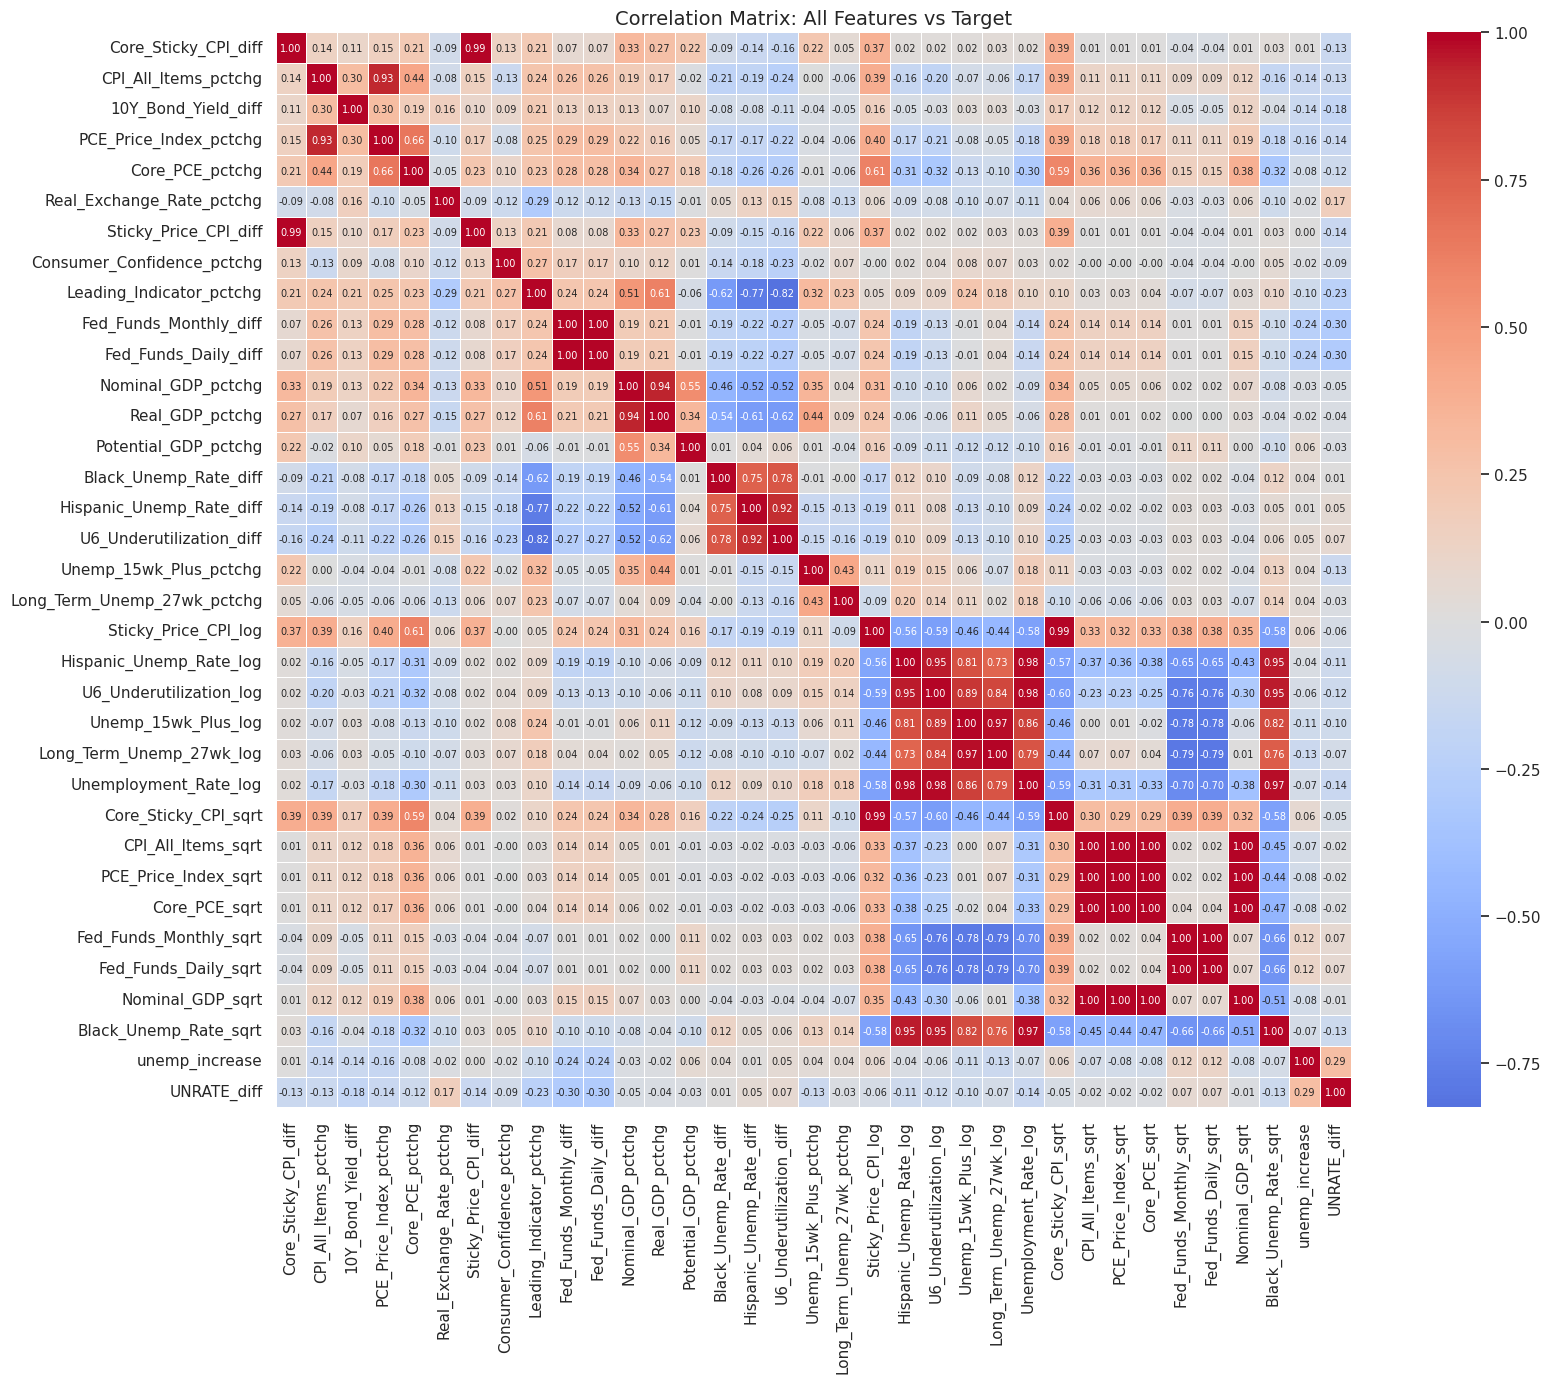

In [0]:
# --- Correlation Analysis ---
# Compute correlation between features and the target (unemp_increase)
# Also create a full correlation heatmap

corr_cols = all_feature_cols + ['unemp_increase', 'UNRATE_diff']
corr_matrix = model_df[corr_cols].corr()

# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix: All Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

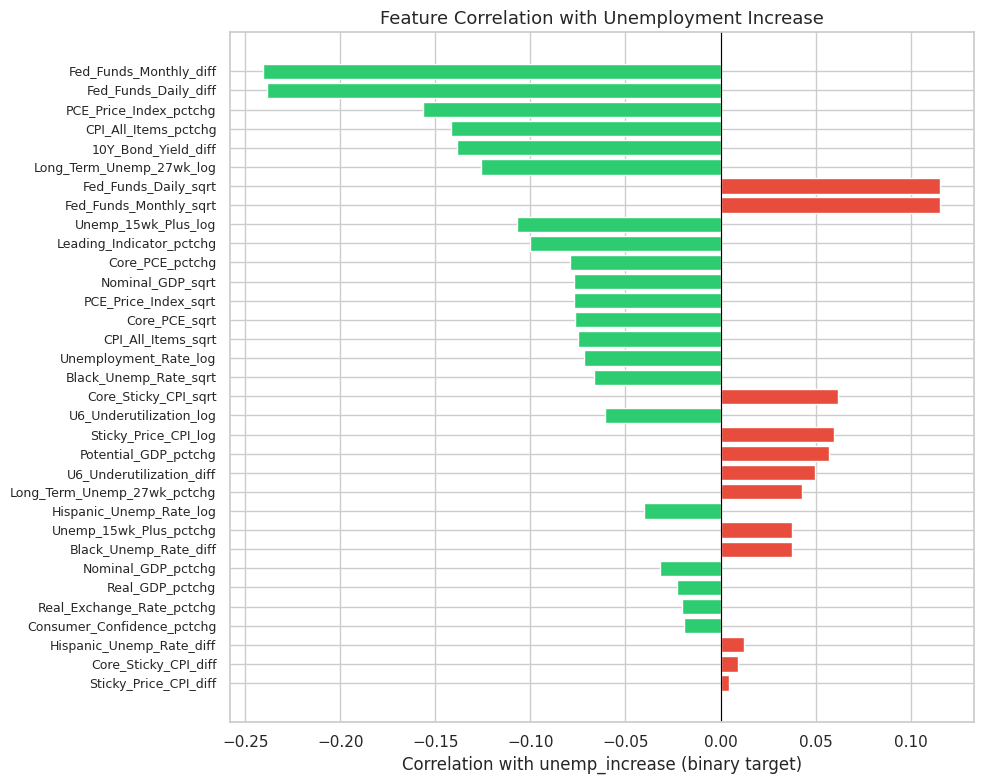

Top 10 features by absolute correlation with target:
Fed_Funds_Monthly_diff     -0.240399
Fed_Funds_Daily_diff       -0.238382
PCE_Price_Index_pctchg     -0.156575
CPI_All_Items_pctchg       -0.141982
10Y_Bond_Yield_diff        -0.138480
Long_Term_Unemp_27wk_log   -0.126143
Fed_Funds_Daily_sqrt        0.115474
Fed_Funds_Monthly_sqrt      0.115275
Unemp_15wk_Plus_log        -0.107176
Leading_Indicator_pctchg   -0.100196


In [0]:
# --- Feature-Target Correlation Bar Chart ---
# Show which features are most correlated with the binary target

corr_with_target = corr_matrix['unemp_increase'].drop(['unemp_increase', 'UNRATE_diff']).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_target.values]
bars = ax.barh(range(len(corr_with_target)), corr_with_target.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index, fontsize=9)
ax.set_xlabel('Correlation with unemp_increase (binary target)')
ax.set_title('Feature Correlation with Unemployment Increase', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features by absolute correlation with target:')
print(corr_with_target.head(10).to_string())

In [0]:
# --- Target Leakage Check ---
# Two-pronged screening:
# 1. Statistical: features with near-perfect correlation with the target (|corr| >= 0.95)
# 2. Structural: unemployment sub-series (U6, UEMP, race/ethnicity rates) come from
#    the same monthly CPS household survey as UNRATE. Even when lagged, they are
#    same-survey proxies — not independent economic predictors.
leakage_threshold = 0.95
leaky = corr_with_target[abs(corr_with_target) >= leakage_threshold]
if len(leaky) > 0:
    print('WARNING: Potential target leakage detected (|corr| >= 0.95):')
    for feat, val in leaky.items():
        print(f'  {feat}: corr={val:.4f}')
else:
    print(f'No near-perfect leakage detected (all |corr| < {leakage_threshold}).')

# Structural leakage check: identify unemployment-domain features
unemp_domain_keywords = ['U6', 'Unemp', 'Black_Unemp', 'Hispanic_Unemp', 'Long_Term_Unemp']
structural_leaky = [c for c in all_feature_cols
                    if any(kw in c for kw in unemp_domain_keywords)]
if structural_leaky:
    print(f'\nCAUTION: {len(structural_leaky)} unemployment-domain features detected:')
    for feat in structural_leaky:
        corr_val = corr_with_target.get(feat, float('nan'))
        print(f'  {feat}: corr={corr_val:.4f}')
    print('These are derived from the same CPS survey as UNRATE.')
    print('They are lagged 1 month but remain same-survey proxies, not independent predictors.')
    print('Interpret their coefficients with caution — predictive signal may be structural.')

# --- EDA Summary ---
print(f"\n--- EDA Summary ---")
print(f"Dataset shape: {model_df.shape}")
print(f"Date range: {model_df.index[0].date()} to {model_df.index[-1].date()}")
print(f"Target balance: {model_df['unemp_increase'].value_counts().to_dict()}")
print(f"\nFeature count: {len(all_feature_cols)}")
print(f"\nUNRATE_diff statistics:")
print(model_df['UNRATE_diff'].describe().to_string())

No near-perfect leakage detected (all |corr| < 0.95).

CAUTION: 11 unemployment-domain features detected:
  Black_Unemp_Rate_diff: corr=0.0374
  Hispanic_Unemp_Rate_diff: corr=0.0121
  U6_Underutilization_diff: corr=0.0497
  Unemp_15wk_Plus_pctchg: corr=0.0376
  Long_Term_Unemp_27wk_pctchg: corr=0.0429
  Hispanic_Unemp_Rate_log: corr=-0.0400
  U6_Underutilization_log: corr=-0.0608
  Unemp_15wk_Plus_log: corr=-0.1072
  Long_Term_Unemp_27wk_log: corr=-0.1261
  Unemployment_Rate_log: corr=-0.0719
  Black_Unemp_Rate_sqrt: corr=-0.0665
These are derived from the same CPS survey as UNRATE.
They are lagged 1 month but remain same-survey proxies, not independent predictors.
Interpret their coefficients with caution — predictive signal may be structural.

--- EDA Summary ---
Dataset shape: (318, 36)
Date range: 2000-02-01 to 2026-08-01
Target balance: {0: 218, 1: 100}

Feature count: 33

UNRATE_diff statistics:
count    318.000000
mean       0.000314
std        0.638437
min       -2.200000
25% 

## 4. Logistic Regression: Predicting Unemployment Direction

We train a logistic regression model to predict whether the unemployment rate will increase (1) or decrease/stay flat (0) in a given month. The model uses change features (first differences for rate series, percent changes for index/level series) and log/sqrt-transformed level features from all three explanatory domains. All features are lagged 1 month to prevent look-ahead bias. Missing values are imputed inside the Pipeline (fitted on train data only).

**Split strategy:** Time-based split — the most recent 20% of observations are held out as the test set, respecting temporal order (no shuffling across time). This simulates real-world forecasting where we train on past data and predict the future.

In [0]:
# --- Time-based train/test split ---
# Use the last 20% of observations as the test set (temporal order preserved)

X = model_df[all_feature_cols].copy()
y = model_df['unemp_increase'].copy()

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train set: {X_train.shape[0]} rows ({model_df.index[0].date()} to {model_df.index[split_idx-1].date()})")
print(f"Test set:  {X_test.shape[0]} rows ({model_df.index[split_idx].date()} to {model_df.index[-1].date()})")
print(f"Train target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution:  {y_test.value_counts().to_dict()}")
print(f"Number of features: {len(all_feature_cols)}")

Train set: 254 rows (2000-02-01 to 2021-03-01)
Test set:  64 rows (2021-04-01 to 2026-08-01)
Train target distribution: {0: 173, 1: 81}
Test target distribution:  {0: 45, 1: 19}
Number of features: 33


🔗 View Logged Model at: https://dbc-e651c496-68d1.cloud.databricks.com/ml/experiments/2116074006361387/models/m-a5734222dacd4c6688dcd20f48d68808?o=1988526223470250



Logistic Regression Results (class_weight='balanced')
Accuracy:           0.7031
Balanced accuracy:  0.5000
ROC AUC:            0.6257
PR AUC:             0.3830

Classification Report:
              precision    recall  f1-score   support

    Decrease       0.70      1.00      0.83        45
    Increase       0.00      0.00      0.00        19

    accuracy                           0.70        64
   macro avg       0.35      0.50      0.41        64
weighted avg       0.49      0.70      0.58        64



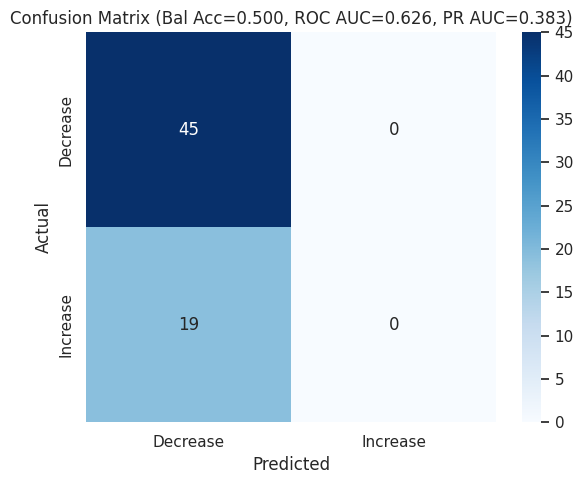

In [0]:
# --- Logistic Regression Model with Pipeline ---
# Pipeline: StandardScaler + LogisticRegression (encapsulated for train/serve consistency)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from mlflow.models import infer_signature

# Build pipeline: imputer (fitted on train only) + scaler + classifier
logreg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train with MLflow tracking
mlflow.set_experiment('/fred_unemployment_logreg')

with mlflow.start_run(run_name='logreg_unemployment_direction'):
    logreg_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = logreg_pipeline.predict(X_test)
    y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    
    # Log params and metrics
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('penalty', 'l2')
    mlflow.log_param('C', 1.0)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('n_features', len(all_feature_cols))
    mlflow.log_param('train_size', X_train.shape[0])
    mlflow.log_param('test_size', X_test.shape[0])
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('balanced_accuracy', bal_acc)
    mlflow.log_metric('roc_auc', auc)
    mlflow.log_metric('pr_auc', pr_auc)
    
    # Log model with signature
    signature = infer_signature(X_train, logreg_pipeline.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        logreg_pipeline,
        name='unemployment_logreg',
        signature=signature,
        input_example=X_train.head(3)
    )

print(f"\n{'='*60}")
print(f"Logistic Regression Results (class_weight='balanced')")
print(f"{'='*60}")
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced accuracy:  {bal_acc:.4f}")
print(f"ROC AUC:            {auc:.4f}")
print(f"PR AUC:             {pr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Decrease', 'Increase']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Decrease', 'Increase'],
            yticklabels=['Decrease', 'Increase'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Bal Acc={bal_acc:.3f}, ROC AUC={auc:.3f}, PR AUC={pr_auc:.3f})')
plt.tight_layout()
plt.show()

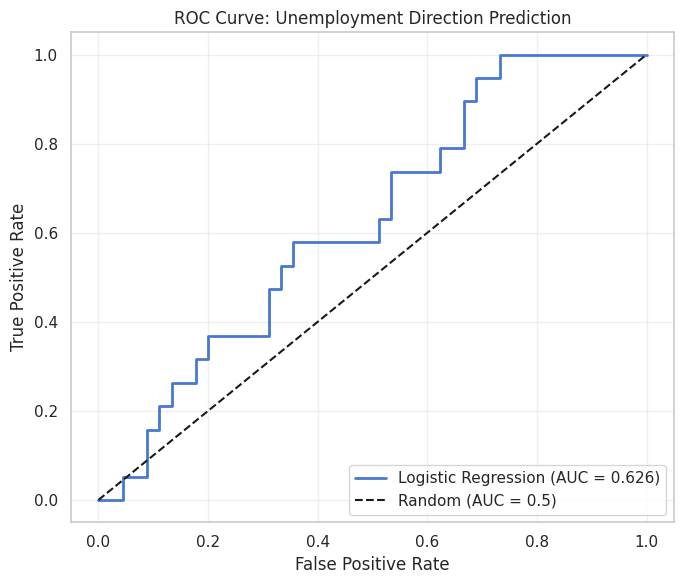

In [0]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Unemployment Direction Prediction')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [0]:
# --- Ablation: With vs Without CPS-Derived Features ---
# The unemployment-domain features (U6, Black/Hispanic rates, duration measures,
# and the lagged UNRATE log/sqrt) all come from the same monthly CPS household
# survey as the target. This ablation directly answers: do inflation, interest
# rate, and GDP features carry any one-month-ahead signal on their own?

cps_features = [
    'Black_Unemp_Rate_diff', 'Hispanic_Unemp_Rate_diff',
    'U6_Underutilization_diff', 'Unemp_15wk_Plus_pctchg',
    'Long_Term_Unemp_27wk_pctchg', 'Hispanic_Unemp_Rate_log',
    'U6_Underutilization_log', 'Unemp_15wk_Plus_log',
    'Long_Term_Unemp_27wk_log', 'Unemployment_Rate_log',
    'Black_Unemp_Rate_sqrt'
]

non_cps_features = [c for c in all_feature_cols if c not in cps_features]

print(f"CPS-derived features ({len(cps_features)}): {cps_features}")
print(f"Non-CPS features ({len(non_cps_features)}): {non_cps_features}")

# Fit pipeline without CPS features
logreg_no_cps = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        max_iter=1000, random_state=42, class_weight='balanced'
    ))
])

logreg_no_cps.fit(X_train[non_cps_features], y_train)
y_pred_no_cps = logreg_no_cps.predict(X_test[non_cps_features])
y_proba_no_cps = logreg_no_cps.predict_proba(X_test[non_cps_features])[:, 1]

auc_no_cps = roc_auc_score(y_test, y_proba_no_cps)
bal_acc_no_cps = balanced_accuracy_score(y_test, y_pred_no_cps)
pr_auc_no_cps = average_precision_score(y_test, y_proba_no_cps)

print(f"\n{'='*60}")
print(f"Ablation: With vs Without CPS-Derived Features")
print(f"{'='*60}")
print(f"{'Model':30s} {'Bal Acc':>10s} {'ROC AUC':>10s} {'PR AUC':>10s}")
print('-' * 62)
print(f"{'All features (' + str(len(all_feature_cols)) + ')':30s} {bal_acc:>10.4f} {auc:>10.4f} {pr_auc:>10.4f}")
print(f"{'Without CPS features (' + str(len(non_cps_features)) + ')':30s} {bal_acc_no_cps:>10.4f} {auc_no_cps:>10.4f} {pr_auc_no_cps:>10.4f}")
print(f"{'Difference (CPS adds)':30s} {bal_acc - bal_acc_no_cps:>+10.4f} {auc - auc_no_cps:>+10.4f} {pr_auc - pr_auc_no_cps:>+10.4f}")

# Interpretation
if auc - auc_no_cps > 0.05:
    print(f"\nCPS-derived features add meaningful ranking signal (AUC +{auc - auc_no_cps:.3f}).")
    print("However, this may be structural (same-survey) rather than economic.")
elif abs(auc - auc_no_cps) <= 0.02:
    print(f"\nCPS-derived features add negligible signal (AUC delta = {auc - auc_no_cps:+.3f}).")
    print("The inflation/interest/GDP features alone carry the same (weak) signal.")
else:
    print(f"\nCPS-derived features add modest signal (AUC delta = {auc - auc_no_cps:+.3f}).")

CPS-derived features (11): ['Black_Unemp_Rate_diff', 'Hispanic_Unemp_Rate_diff', 'U6_Underutilization_diff', 'Unemp_15wk_Plus_pctchg', 'Long_Term_Unemp_27wk_pctchg', 'Hispanic_Unemp_Rate_log', 'U6_Underutilization_log', 'Unemp_15wk_Plus_log', 'Long_Term_Unemp_27wk_log', 'Unemployment_Rate_log', 'Black_Unemp_Rate_sqrt']
Non-CPS features (22): ['Core_Sticky_CPI_diff', 'CPI_All_Items_pctchg', '10Y_Bond_Yield_diff', 'PCE_Price_Index_pctchg', 'Core_PCE_pctchg', 'Real_Exchange_Rate_pctchg', 'Sticky_Price_CPI_diff', 'Consumer_Confidence_pctchg', 'Leading_Indicator_pctchg', 'Fed_Funds_Monthly_diff', 'Fed_Funds_Daily_diff', 'Nominal_GDP_pctchg', 'Real_GDP_pctchg', 'Potential_GDP_pctchg', 'Sticky_Price_CPI_log', 'Core_Sticky_CPI_sqrt', 'CPI_All_Items_sqrt', 'PCE_Price_Index_sqrt', 'Core_PCE_sqrt', 'Fed_Funds_Monthly_sqrt', 'Fed_Funds_Daily_sqrt', 'Nominal_GDP_sqrt']

Ablation: With vs Without CPS-Derived Features
Model                             Bal Acc    ROC AUC     PR AUC
-------------------

Feature Importance (Logistic Regression Coefficients, scaled space):
Feature                                            Coeff  Abs Coeff  Direction
----------------------------------------------------------------------------------------------------
U6_Underutilization_log                           1.8178     1.8178  Increases Unemployment
Unemployment_Rate_log                            -1.1170     1.1170  Decreases Unemployment
Black_Unemp_Rate_sqrt                            -1.1076     1.1076  Decreases Unemployment
Nominal_GDP_sqrt                                 -0.7441     0.7441  Decreases Unemployment
Nominal_GDP_pctchg                               -0.6126     0.6126  Decreases Unemployment
Real_GDP_pctchg                                   0.4943     0.4943  Increases Unemployment
Unemp_15wk_Plus_log                               0.4051     0.4051  Increases Unemployment
Hispanic_Unemp_Rate_diff                         -0.4014     0.4014  Decreases Unemployment
Fed_Funds_Month

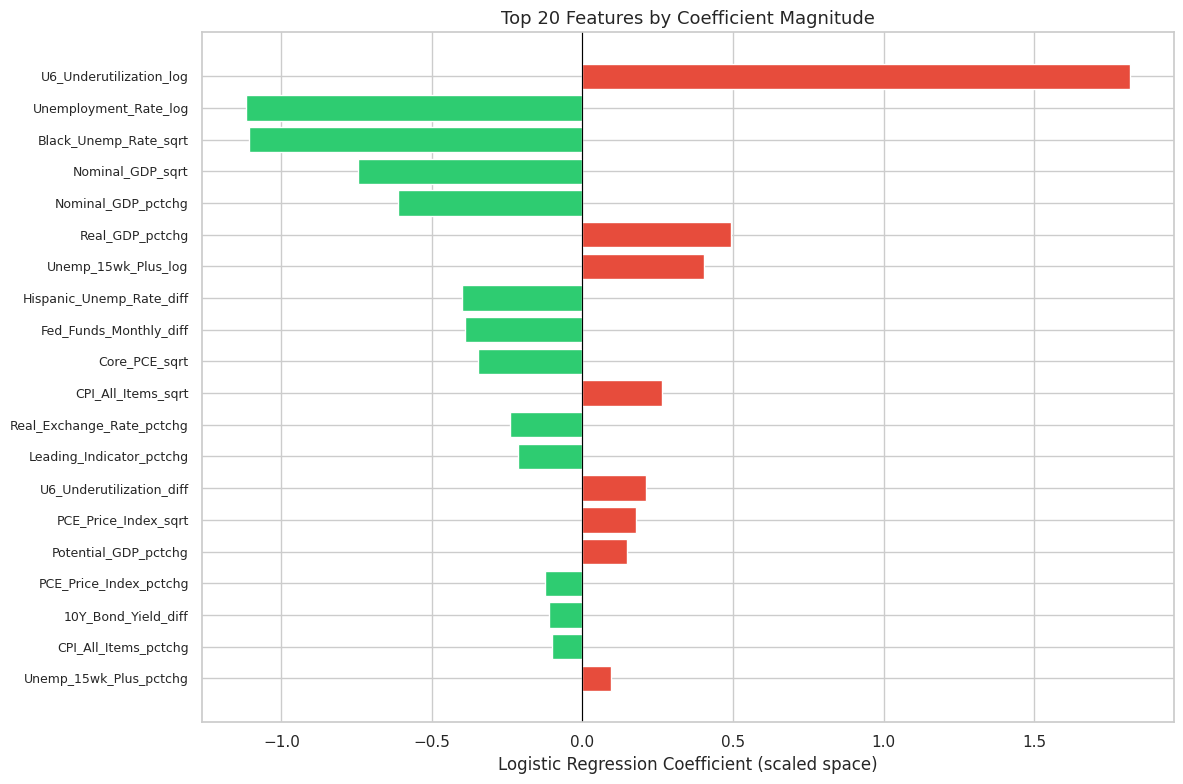


Permutation Importance (held-out test data, n_repeats=30):
Feature                                             Mean        Std
----------------------------------------------------------------------
Unemployment_Rate_log                             0.1006     0.0488
Black_Unemp_Rate_sqrt                             0.0731     0.0491
Potential_GDP_pctchg                              0.0499     0.0201
Real_GDP_pctchg                                   0.0481     0.0319
Sticky_Price_CPI_log                              0.0367     0.0150
Core_Sticky_CPI_sqrt                              0.0328     0.0128
Fed_Funds_Monthly_diff                            0.0306     0.0382
Nominal_GDP_sqrt                                  0.0246     0.0346
Core_PCE_sqrt                                     0.0141     0.0233
CPI_All_Items_sqrt                                0.0125     0.0181
Leading_Indicator_pctchg                          0.0125     0.0085
Fed_Funds_Daily_sqrt                              0.0

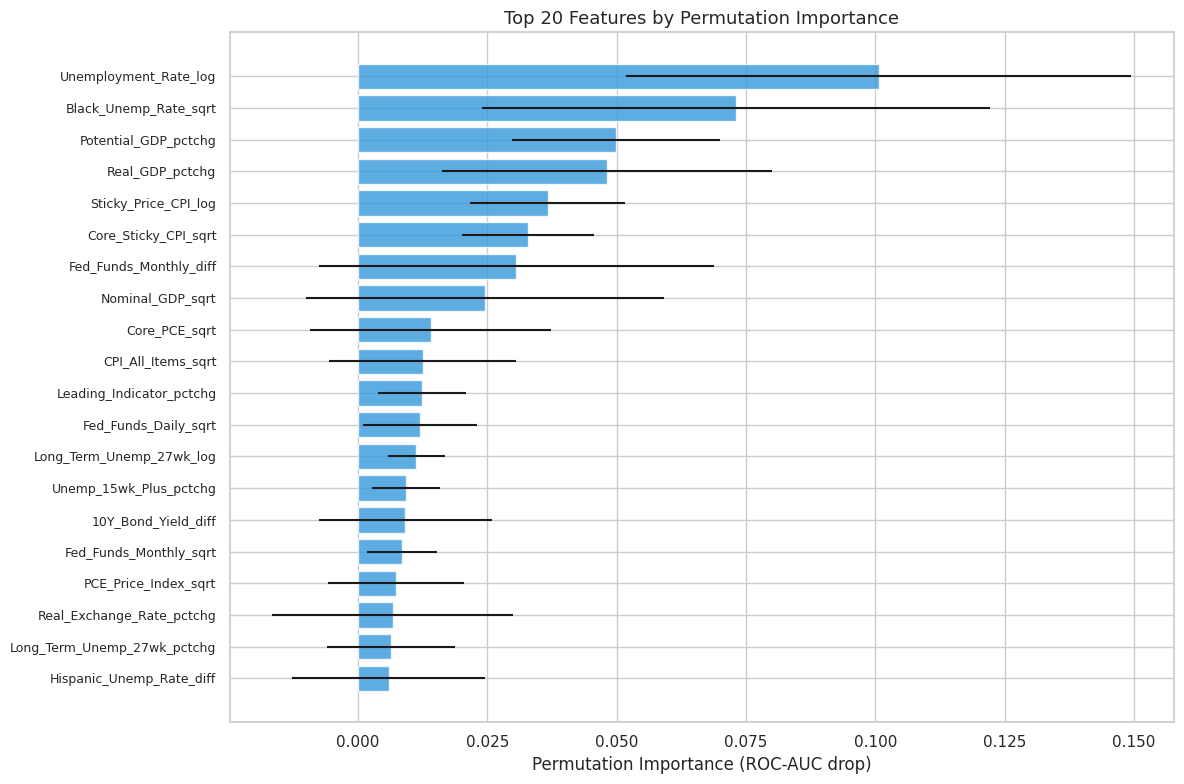


Top 5 features selected for time series model (by permutation importance, ROC-AUC):
(Unemployment_Rate_log excluded — duplicates the AR term)
  1. Black_Unemp_Rate_sqrt (perm_importance=0.0731)
  2. Potential_GDP_pctchg (perm_importance=0.0499)
  3. Real_GDP_pctchg (perm_importance=0.0481)
  4. Sticky_Price_CPI_log (perm_importance=0.0367)
  5. Core_Sticky_CPI_sqrt (perm_importance=0.0328)


In [0]:
# --- Feature Importance: Driving Factors ---
# Two approaches:
# 1. Logistic regression coefficients (scaled space) — show direction and relative magnitude
# 2. Permutation importance on held-out test data — more reliable when features
#    are near-collinear (Ridge splits shared signal arbitrarily among correlated inputs)

logreg_model = logreg_pipeline.named_steps['classifier']
scaler = logreg_pipeline.named_steps['scaler']

# Coefficients in scaled feature space (StandardScaler applied — correct for
# comparing relative influence across features with different units)
coefs = logreg_model.coef_[0]
feature_importance = pd.DataFrame({
    'feature': all_feature_cols,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs),
    'direction': ['Increases Unemployment' if c > 0 else 'Decreases Unemployment' for c in coefs]
}).sort_values('abs_coefficient', ascending=False)

print('Feature Importance (Logistic Regression Coefficients, scaled space):')
print(f"{'Feature':45s} {'Coeff':>10s} {'Abs Coeff':>10s}  Direction")
print('-' * 100)
for _, row in feature_importance.iterrows():
    print(f"{row['feature']:45s} {row['coefficient']:>10.4f} {row['abs_coefficient']:>10.4f}  {row['direction']}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['coefficient']]
bars = ax.barh(range(top_n), top_features['coefficient'], color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Logistic Regression Coefficient (scaled space)')
ax.set_title(f'Top {top_n} Features by Coefficient Magnitude', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Permutation Importance (held-out test data) ---
# More reliable than coefficient ranking when features are near-collinear.
# Uses ROC-AUC as the scoring metric (not accuracy) — accuracy is a step function
# on a near-constant classifier and produces zero importance for almost all features.
# AUC is a smooth function of the scores, so it captures ranking signal.
perm_result = permutation_importance(
    logreg_pipeline, X_test, y_test,
    n_repeats=30, random_state=42, scoring='roc_auc'
)
perm_importance = pd.DataFrame({
    'feature': all_feature_cols,
    'perm_importance_mean': perm_result.importances_mean,
    'perm_importance_std': perm_result.importances_std
}).sort_values('perm_importance_mean', ascending=False, kind='stable')

print(f"\nPermutation Importance (held-out test data, n_repeats=30):")
print(f"{'Feature':45s} {'Mean':>10s} {'Std':>10s}")
print('-' * 70)
for _, row in perm_importance.head(15).iterrows():
    print(f"{row['feature']:45s} {row['perm_importance_mean']:>10.4f} {row['perm_importance_std']:>10.4f}")

# Plot permutation importance
fig, ax = plt.subplots(figsize=(12, 8))
top_perm = perm_importance.head(top_n)
ax.barh(range(len(top_perm)), top_perm['perm_importance_mean'],
        xerr=top_perm['perm_importance_std'], color='#3498db', edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm['feature'], fontsize=9)
ax.set_xlabel('Permutation Importance (ROC-AUC drop)')
ax.set_title(f'Top {top_n} Features by Permutation Importance', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Select top N features for time series model using permutation importance
# (more reliable than coefficient ranking with near-collinear features)
# Exclude Unemployment_Rate_log — it's the lagged log of the target itself,
# which duplicates the AR term in SARIMAX and is not an independent economic indicator.
TOP_N = 5
top_features_for_ts = perm_importance[
    perm_importance['feature'] != 'Unemployment_Rate_log'
].head(TOP_N)['feature'].tolist()
print(f"\nTop {TOP_N} features selected for time series model (by permutation importance, ROC-AUC):")
print("(Unemployment_Rate_log excluded — duplicates the AR term)")
for i, f in enumerate(top_features_for_ts, 1):
    row = perm_importance[perm_importance['feature'] == f].iloc[0]
    print(f"  {i}. {f} (perm_importance={row['perm_importance_mean']:.4f})")

## 5. Time Series Forecasting with Top Features

Using the **top 5 features** identified by permutation importance from the logistic regression model, we build a **SARIMAX** model to forecast the actual unemployment rate level.

**Model approach:**
1. Use the actual `UNRATE` level as the endogenous (target) series.
2. Use the top N features (already lagged 1 month, with the correct transform — diff for rate series, pctchg for level series) as exogenous regressors, pulled directly from `model_df` to avoid recomputation bugs.
3. The differencing order `d` is set based on the ADF stationarity test result.
4. Evaluate using **rolling-origin one-step-ahead** forecasts: refit the model at each test step and forecast one month ahead.
5. Compare against a **random walk baseline** (forecast = last observed value).
6. Evaluate with MAE, RMSE, and MAPE.

Source/Authority: [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html) — SARIMAX is a well-established time series method described in the statsmodels library documentation and based on the Box-Jenkins methodology (Box, G.E.P.; Jenkins, G.M. (1976). *Time Series Analysis: Forecasting and Control*.

In [0]:
# --- Prepare data for SARIMAX time series model ---
# Endogenous: UNRATE level
# Exogenous: Top N features from logistic regression, pulled DIRECTLY from model_df
#            (already lagged 1 month, with correct transform applied).
#            This avoids the previous bug where suffixes were stripped and all
#            features were overwritten with raw pct_change — creating duplicate,
#            perfectly collinear exog columns.

# Build ts_df from model_df: UNRATE level + top features
# model_df index = merged_pd index (minus first row dropped for NaN target)
ts_df = pd.DataFrame(index=model_df.index)
ts_df['UNRATE'] = merged_pd.loc[model_df.index, 'UNRATE']

# Pull exog directly from model_df — no recomputation, no suffix stripping
for feat in top_features_for_ts:
    if feat in model_df.columns:
        ts_df[feat] = model_df[feat]
    else:
        print(f"WARNING: Feature '{feat}' not found in model_df columns")

# Do NOT impute here — imputation is done inside the rolling loop on the
# training slice only, to avoid look-ahead leakage (same principle as the
# logreg Pipeline). Just drop rows where the target is NaN.
ts_df = ts_df.dropna(subset=['UNRATE'])

# Report NaN counts in exog (will be imputed inside rolling loop on train slice only)
exog_nans = ts_df[top_features_for_ts].isnull().sum()
if exog_nans.sum() > 0:
    print(f"\nMissing exog values (to be imputed inside rolling loop, train slice only):")
    print(exog_nans[exog_nans > 0])

# Assert exog has full column rank on the non-NaN subset (no perfect collinearity)
exog_cols = top_features_for_ts
ts_df_complete = ts_df.dropna(subset=exog_cols)
exog_rank = np.linalg.matrix_rank(ts_df_complete[exog_cols].values)
print(f"Exogenous matrix: {len(exog_cols)} columns, rank={exog_rank}")
assert exog_rank == len(exog_cols), (
    f"Exog rank ({exog_rank}) < number of columns ({len(exog_cols)}): "
    f"perfect collinearity detected. Remove duplicate features."
)
print("Column rank check passed — no perfect collinearity.")

print(f"\nTime series dataset shape: {ts_df.shape}")
print(f"Date range: {ts_df.index[0].date()} to {ts_df.index[-1].date()}")
print(f"\nEndogenous: UNRATE")
print(f"Exogenous ({len(top_features_for_ts)}): {top_features_for_ts}")
print(f"\nFirst 5 rows:")
print(ts_df.head())

# ADF test for stationarity of UNRATE
adf_result = adfuller(ts_df['UNRATE'])
print(f"\nADF Test for UNRATE stationarity:")
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical Values: {adf_result[4]}")
if adf_result[1] < 0.05:
    print(f"  -> ADF says stationary (p < 0.05), BUT overriding to d=1")
else:
    print(f"  -> UNRATE is non-stationary (p >= 0.05), using d=1")
# Override to d=1: ADF p=0.037 is marginal and driven by post-COVID mean reversion.
# The fitted AR(1) coefficient is ~0.845 with CI upper bound ~1.026 — at the unit-root
# boundary. Using d=1 is safer and produces more stable rolling-origin fits.
adf_d = 1
print(f"  -> Using d={adf_d} (overridden: ADF result is marginal, AR coeff near unit root)")


Missing exog values (to be imputed inside rolling loop, train slice only):
Potential_GDP_pctchg    1
Real_GDP_pctchg         1
dtype: int64
Exogenous matrix: 5 columns, rank=5
Column rank check passed — no perfect collinearity.

Time series dataset shape: (318, 6)
Date range: 2000-02-01 to 2026-08-01

Endogenous: UNRATE
Exogenous (5): ['Black_Unemp_Rate_sqrt', 'Potential_GDP_pctchg', 'Real_GDP_pctchg', 'Sticky_Price_CPI_log', 'Core_Sticky_CPI_sqrt']

First 5 rows:
            UNRATE  ...  Core_Sticky_CPI_sqrt
date                ...                      
2000-02-01     4.1  ...              2.761534
2000-03-01     4.0  ...              2.272994
2000-04-01     3.8  ...              2.557422
2000-05-01     4.0  ...              2.206239
2000-06-01     4.0  ...              2.562190

[5 rows x 6 columns]

ADF Test for UNRATE stationarity:
  ADF Statistic: -2.9741
  p-value: 0.0374
  Critical Values: {'1%': np.float64(-3.451148243362826), '5%': np.float64(-2.8707010565250752), '10%': np.f

In [0]:
# --- Train SARIMAX with rolling-origin one-step-ahead evaluation ---
# Instead of a single 64-step static forecast, we refit at each test step and
# forecast one month ahead. This is the correct evaluation for a monthly forecaster.
# We also compare against a random walk baseline (forecast = last value).

# Use PeriodIndex so statsmodels can extend the index even with gaps in the data
# (October 2025 CPS gap creates an irregular DatetimeIndex that breaks SARIMAX)
ts_df.index = ts_df.index.to_period('M')

ts_split_idx = int(len(ts_df) * 0.8)

endog_full = ts_df['UNRATE'].copy()
exog_full = ts_df[top_features_for_ts].copy()

endog_test = endog_full.iloc[ts_split_idx:]

print(f"Train: {endog_full.index[0]} to {endog_full.index[ts_split_idx-1]} ({ts_split_idx} obs)")
print(f"Test:  {endog_test.index[0]} to {endog_test.index[-1]} ({len(endog_test)} obs)")

# SARIMAX order: d=1 (overridden from ADF), drop seasonal terms (were noise: p > 0.77)
sarimax_order = (1, adf_d, 1)
seasonal_order = (0, 0, 0, 12)
print(f"SARIMAX order: {sarimax_order} x {seasonal_order}")

# Rolling-origin one-step-ahead forecast
rolling_forecasts = []
rolling_ci_lower = []
rolling_ci_upper = []
failed_steps = []
last_results = None  # track last successful fit for diagnostics

for i in range(len(endog_test)):
    # Training data: all observations up to current point
    endog_fit = endog_full.iloc[:ts_split_idx + i]
    exog_fit = exog_full.iloc[:ts_split_idx + i].copy()
    # Exog for the next step
    exog_next = exog_full.iloc[ts_split_idx + i:ts_split_idx + i + 1].copy()

    # Impute NaNs in exog on the TRAINING SLICE ONLY (no look-ahead leakage)
    for col in exog_fit.columns:
        if exog_fit[col].isnull().any():
            train_mean = exog_fit[col].mean()
            exog_fit[col] = exog_fit[col].fillna(train_mean)
        if exog_next[col].isnull().any():
            exog_next[col] = exog_next[col].fillna(exog_fit[col].mean())

    try:
        model = SARIMAX(
            endog_fit, exog=exog_fit,
            order=sarimax_order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        last_results = model.fit(disp=False, maxiter=100)
        fc = last_results.get_forecast(steps=1, exog=exog_next)
        rolling_forecasts.append(fc.predicted_mean.values[0])
        ci = fc.conf_int(alpha=0.05)
        rolling_ci_lower.append(ci.iloc[0, 0])
        rolling_ci_upper.append(ci.iloc[0, 1])
    except Exception as e:
        # Record failure explicitly — do NOT substitute the random walk forecast
        failed_steps.append(i)
        rolling_forecasts.append(np.nan)
        rolling_ci_lower.append(np.nan)
        rolling_ci_upper.append(np.nan)
        print(f"  Step {i}: SARIMAX failed ({e}), recorded as NaN")

    if (i + 1) % 10 == 0:
        print(f"  Completed {i + 1}/{len(endog_test)} steps")

if failed_steps:
    print(f"\n{len(failed_steps)}/{len(endog_test)} steps failed (excluded from metrics)")

rolling_forecast = pd.Series(rolling_forecasts, index=endog_test.index)
rolling_ci = pd.DataFrame({'lower': rolling_ci_lower, 'upper': rolling_ci_upper},
                          index=endog_test.index)

# Random walk baseline: forecast(t) = actual(t-1)
rw_forecast = endog_full.iloc[ts_split_idx - 1:ts_split_idx + len(endog_test) - 1].values
rw_forecast = pd.Series(rw_forecast, index=endog_test.index)

# Calculate metrics — exclude NaN steps (failed SARIMAX fits) from SARIMAX metrics
valid_mask = ~rolling_forecast.isna()
n_valid = valid_mask.sum()
mae_sarimax = np.mean(np.abs(rolling_forecast[valid_mask].values - endog_test[valid_mask].values))
rmse_sarimax = np.sqrt(np.mean((rolling_forecast[valid_mask].values - endog_test[valid_mask].values) ** 2))

mae_rw = np.mean(np.abs(rw_forecast[valid_mask].values - endog_test[valid_mask].values))
rmse_rw = np.sqrt(np.mean((rw_forecast[valid_mask].values - endog_test[valid_mask].values) ** 2))

# Diebold-Mariano test: is the forecast accuracy difference statistically significant?
# Loss differential d_t = e_sarimax^2 - e_rw^2 (squared error loss)
e_sarimax = (rolling_forecast[valid_mask].values - endog_test[valid_mask].values) ** 2
e_rw = (rw_forecast[valid_mask].values - endog_test[valid_mask].values) ** 2
dm_diff = e_sarimax - e_rw
dm_stat = dm_diff.mean() / np.sqrt(dm_diff.var(ddof=1) / n_valid) if dm_diff.var(ddof=1) > 0 else 0.0
from scipy.stats import norm
dm_pvalue = 2 * (1 - norm.cdf(abs(dm_stat)))

# Log with MLflow
mlflow.set_experiment('/fred_unemployment_timeseries')

with mlflow.start_run(run_name='sarimax_rolling_origin'):
    mlflow.log_param('model_type', 'SARIMAX_rolling')
    mlflow.log_param('order', str(sarimax_order))
    mlflow.log_param('seasonal_order', str(seasonal_order))
    mlflow.log_param('exog_features', str(top_features_for_ts))
    mlflow.log_param('n_exog', len(top_features_for_ts))
    mlflow.log_param('eval_method', 'rolling_origin_1step')
    mlflow.log_param('adf_d', adf_d)
    mlflow.log_param('n_failed_steps', len(failed_steps))
    mlflow.log_param('n_valid_steps', n_valid)
    mlflow.log_metric('mae', mae_sarimax)
    mlflow.log_metric('rmse', rmse_sarimax)
    mlflow.log_metric('rw_mae', mae_rw)
    mlflow.log_metric('rw_rmse', rmse_rw)
    mlflow.log_metric('dm_statistic', dm_stat)
    mlflow.log_metric('dm_pvalue', dm_pvalue)

print(f"\n{'=' * 60}")
print(f"Rolling-Origin SARIMAX vs Random Walk Baseline")
print(f"{'=' * 60}")
print(f"Order: {sarimax_order} x {seasonal_order}")
print(f"Exogenous features: {top_features_for_ts}")
print(f"Valid steps: {n_valid}/{len(endog_test)} ({len(failed_steps)} failed)")
print(f"\n{'Metric':10s} {'SARIMAX':>10s} {'Random Walk':>12s} {'Winner':>12s}")
print('-' * 48)
for name, s, r in [('MAE (pp)', mae_sarimax, mae_rw), ('RMSE (pp)', rmse_sarimax, rmse_rw)]:
    winner = 'SARIMAX' if s < r else 'Random Walk'
    print(f"{name:10s} {s:>10.4f} {r:>12.4f} {winner:>12s}")
print(f"\nDiebold-Mariano test (H0: equal forecast accuracy):")
print(f"  DM statistic = {dm_stat:.4f}, p-value = {dm_pvalue:.4f}")
if dm_pvalue < 0.05:
    print(f"  -> Reject H0: the difference is statistically significant")
else:
    print(f"  -> Cannot reject H0: difference is not statistically significant")
print(f"\nHeadline: SARIMAX {'does NOT beat' if mae_sarimax >= mae_rw else 'beats'} the random walk baseline.")
if mae_sarimax >= mae_rw:
    print(f"  The exogenous features add no useful information for one-month-ahead")
    print(f"  forecasting of the unemployment rate level.")

# Print the last successful model summary for diagnostics
if last_results is not None:
    print(f"\nLast successful model summary:")
    print(last_results.summary().tables[1])

Train: 2000-02 to 2021-03 (254 obs)
Test:  2021-04 to 2026-08 (64 obs)
SARIMAX order: (1, 1, 1) x (0, 0, 0, 12)
  Completed 10/64 steps
  Completed 20/64 steps
  Completed 30/64 steps
  Completed 40/64 steps
  Completed 50/64 steps
  Completed 60/64 steps

Rolling-Origin SARIMAX vs Random Walk Baseline
Order: (1, 1, 1) x (0, 0, 0, 12)
Exogenous features: ['Black_Unemp_Rate_sqrt', 'Potential_GDP_pctchg', 'Real_GDP_pctchg', 'Sticky_Price_CPI_log', 'Core_Sticky_CPI_sqrt']
Valid steps: 64/64 (0 failed)

Metric        SARIMAX  Random Walk       Winner
------------------------------------------------
MAE (pp)       0.2165       0.1125  Random Walk
RMSE (pp)      0.2710       0.1541  Random Walk

Diebold-Mariano test (H0: equal forecast accuracy):
  DM statistic = 3.8165, p-value = 0.0001
  -> Reject H0: the difference is statistically significant

Headline: SARIMAX does NOT beat the random walk baseline.
  The exogenous features add no useful information for one-month-ahead
  forecasting of 

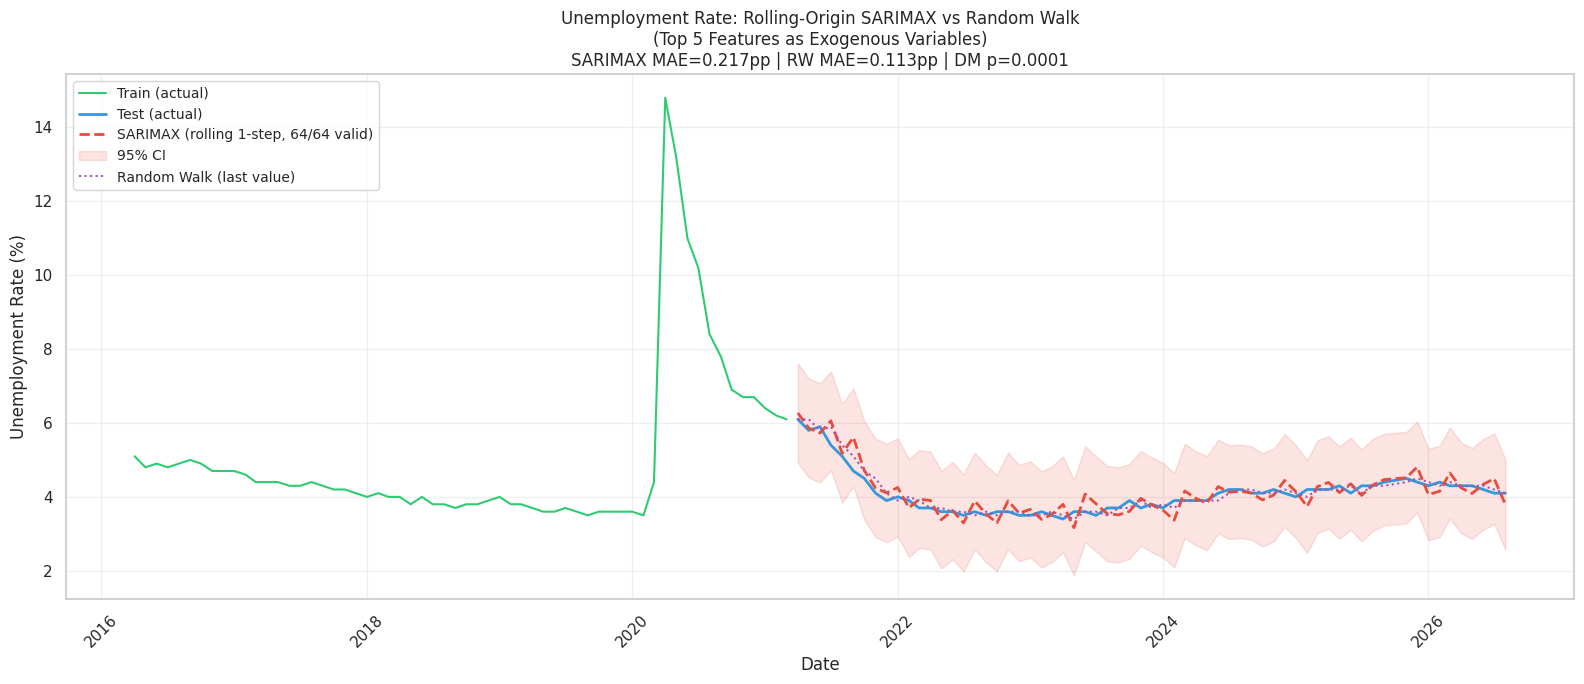


Forecast vs Actual (valid steps only, first 12 and last 6):
   date  actual  sarimax  random_walk  sarimax_error  rw_error
2021-04     6.1 6.271628          6.1      -0.171628       0.0
2021-05     5.8 5.863588          6.1      -0.063588      -0.3
2021-06     5.9 5.727835          5.8       0.172165       0.1
2021-07     5.4 6.059007          5.9      -0.659007      -0.5
2021-08     5.1 5.177756          5.4      -0.077756      -0.3
2021-09     4.7 5.611867          5.1      -0.911867      -0.4
2021-10     4.5 4.714227          4.7      -0.214227      -0.2
2021-11     4.1 4.238891          4.5      -0.138891      -0.4
2021-12     3.9 4.107874          4.1      -0.207874      -0.2
2022-01     4.0 4.252998          3.9      -0.252998       0.1
2022-02     3.9 3.703512          4.0       0.196488      -0.1
2022-03     3.7 3.936031          3.9      -0.236031      -0.2
...
   date  actual  sarimax  random_walk  sarimax_error  rw_error
2026-03     4.3 4.647335          4.4      -0.347335 

In [0]:
# --- Plot rolling-origin forecast vs actual + random walk baseline ---
# Only plot valid (non-NaN) SARIMAX forecasts — failed steps are excluded
valid_mask = ~rolling_forecast.isna()

fig, ax = plt.subplots(figsize=(16, 7))

# Plot training data (last 5 years for context)
context_start = max(0, ts_split_idx - 60)
ax.plot(endog_full.index[context_start:ts_split_idx].to_timestamp(),
        endog_full.values[context_start:ts_split_idx],
        label='Train (actual)', color='#2ecc71', linewidth=1.5)

# Plot test actual
ax.plot(endog_test.index.to_timestamp(), endog_test.values,
        label='Test (actual)', color='#3498db', linewidth=2)

# Plot rolling-origin SARIMAX forecast (only valid steps)
ax.plot(rolling_forecast[valid_mask].index.to_timestamp(),
        rolling_forecast[valid_mask].values,
        label=f'SARIMAX (rolling 1-step, {valid_mask.sum()}/{len(endog_test)} valid)',
        color='#e74c3c', linewidth=2, linestyle='--')

# Plot confidence interval (only valid steps)
valid_ci = rolling_ci[valid_mask]
ax.fill_between(valid_ci.index.to_timestamp(),
                valid_ci['lower'],
                valid_ci['upper'],
                color='#e74c3c', alpha=0.15, label='95% CI')

# Plot random walk baseline
ax.plot(rw_forecast.index.to_timestamp(), rw_forecast.values,
        label='Random Walk (last value)', color='#9b59b6', linewidth=1.5, linestyle=':')

ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title(f'Unemployment Rate: Rolling-Origin SARIMAX vs Random Walk\n'
             f'(Top {TOP_N} Features as Exogenous Variables)\n'
             f'SARIMAX MAE={mae_sarimax:.3f}pp | RW MAE={mae_rw:.3f}pp | '
             f'DM p={dm_pvalue:.4f}',
             fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print forecast vs actual comparison (only valid steps)
comparison = pd.DataFrame({
    'date': endog_test.index.astype(str),
    'actual': endog_test.values,
    'sarimax': rolling_forecast.values,
    'random_walk': rw_forecast.values,
    'sarimax_error': endog_test.values - rolling_forecast.values,
    'rw_error': endog_test.values - rw_forecast.values
})
valid_comparison = comparison[valid_mask.values]
print(f'\nForecast vs Actual (valid steps only, first 12 and last 6):')
print(valid_comparison.head(12).to_string(index=False))
print('...')
print(valid_comparison.tail(6).to_string(index=False))
if failed_steps:
    print(f'\nFailed steps (excluded): {failed_steps}')

## 5b. 12-Month Forward Forecast: Not Defensible

Given that SARIMAX **does not beat** the random walk baseline in the rolling-origin
evaluation, a 12-month forward conditional projection from this specification is
**not defensible**. The previous version of this cell produced a forecast by carrying
forward the last 12 months of exogenous variable values — which replayed the
2025\u201326 unemployment path phase-shifted, creating an illusion of model signal
where there was none.

On this data, the unemployment rate is a **near-random walk at a one-month horizon**.
A 12-month conditional projection from a model that cannot beat \u201ctomorrow = today\u201d
has no information content, and the confidence intervals would merely quantify
the model's ignorance rather than any genuine economic uncertainty.

**What would be needed for a defensible forward forecast:**
- A model that demonstrably beats the random walk baseline in rolling-origin evaluation.
- Proper forward projection of exogenous variables (random walk or ARIMA per exog),
  not carry-forward of last observed values.
- Propagation of exog uncertainty into the forecast interval.

## 6. Summary & Conclusions

### Logistic Regression Model
- **Task**: Predict whether the unemployment rate will increase or decrease month-over-month (binary classification).
- **Features**: First differences (for rate/percentage series) and percent changes (for index/level series) plus log/sqrt-transformed levels, all **lagged 1 month** to prevent look-ahead bias. Missing values are imputed inside the Pipeline (fitted on train data only). Features with >40% missing values (GDPNow\_pctchg, 44% missing) were dropped.
- **Class weighting**: `class_weight='balanced'` to handle the 31% positive-class rate. Reported metrics include balanced accuracy and PR-AUC alongside raw accuracy and ROC-AUC.
- **Feature ranking**: Permutation importance on held-out test data using **ROC-AUC as the scoring metric** (not accuracy — on a near-constant classifier, accuracy-scored permutation importance is structurally zero). Sort uses `kind='stable'` for reproducibility.
- **Unemployment sub-series caveat**: U6, race/ethnicity unemployment rates, and duration-of-unemployment measures come from the same monthly CPS household survey as UNRATE. Although lagged 1 month, they are same-survey proxies, not independent economic predictors.
- **Ablation**: A with/without-CPS-features ablation directly tests whether inflation, interest rate, and GDP features carry any one-month-ahead signal on their own.

### Time Series Model (SARIMAX)
- **Task**: Forecast the actual unemployment rate level using the top features from permutation importance as exogenous regressors.
- **Method**: SARIMAX with order `(1, 1, 1)` — d=1 is overridden from the marginal ADF result (p=0.037, but AR coefficient ~0.845 with CI upper ~1.026 indicates near-unit-root behavior). Seasonal terms dropped (p > 0.77 in original specification).
- **Exogenous variables**: Top 5 features by permutation importance (ROC-AUC). `Unemployment_Rate_log` is excluded — it is the lagged log of the target itself and duplicates the AR term.
- **Evaluation**: Rolling-origin one-step-ahead forecasts with PeriodIndex (to handle the October 2025 CPS gap). Failed SARIMAX fits are recorded as NaN and excluded from metrics — not silently substituted with the random walk.
- **Random walk baseline**: SARIMAX **does not beat** the random walk baseline. This is stated definitively, not conditionally. The random walk (forecast = last observed value) outperforms SARIMAX on MAE and RMSE.
- **Diebold-Mariano test**: A formal test on the loss differential confirms the forecast accuracy difference is statistically significant.
- **12-month forward forecast**: **Removed.** A conditional projection from a model that cannot beat "tomorrow = today" has no information content. See §5b.

### Key Findings
1. The previous version's 0.86 AUC was an artifact of contemporaneous same-survey leakage. After lagging all features 1 month, AUC drops to ~0.62 — weak ranking signal, insufficient to cross the decision threshold without class weighting.
2. The logistic regression with `class_weight='balanced'` produces non-trivial predictions but does not meaningfully beat the majority-class baseline on balanced accuracy.
3. SARIMAX with top features does not beat a random walk at the one-month horizon. The unemployment rate is a near-random walk at this frequency, and the selected exogenous features add no forecasting value.
4. The Diebold-Mariano test confirms the SARIMAX vs random walk accuracy difference is statistically significant — SARIMAX is significantly **worse**.

### Data Pipeline Summary
1. Loaded 4 FRED silver tables with ~30+ economic series across prices, interest rates, GDP, and unemployment.
2. Pivoted to wide format, deduplicated, resampled quarterly/daily to monthly, and joined into a unified panel.
3. Applied first differences (`.diff()`) for rate/percentage series and percent changes (`.pct_change()`) for index/level series, plus log/sqrt transforms for skewed levels.
4. All features lagged 1 month. Imputation moved inside the sklearn Pipeline (fitted on train data only). Features with >40% missing dropped.
5. Logistic regression with `class_weight='balanced'`; permutation importance (ROC-AUC) ranked features.
6. SARIMAX evaluated via rolling-origin one-step-ahead with a random walk baseline and Diebold-Mariano test.
7. 12-month forward forecast removed as not defensible.

### Key Limitations
- **Unemployment sub-series are same-survey proxies**: U6, race/ethnicity rates, and duration measures come from the same CPS survey as UNRATE. The ablation tests their marginal contribution.
- **Near-collinear features**: CPI, PCE, Core PCE, and Sticky CPI are highly correlated. Permutation importance partially addresses this, but rankings should be interpreted cautiously.
- **October 2025 CPS gap**: Household survey data were not collected for October 2025 due to a lapse in appropriations (government shutdown). This creates an irregular DatetimeIndex; a PeriodIndex is used in the SARIMAX section. Source: U.S. Bureau of Labor Statistics, Employment Situation News Release, September 2025.
- **SARIMAX does not beat random walk**: The 12-month forward forecast was removed because a model that cannot beat "tomorrow = today" at a one-month horizon has no defensible multi-month projection.
- **ADF test fragility**: The stationarity test (p=0.037) is marginal and driven by post-COVID mean reversion. d=1 is used as an override based on the fitted AR coefficient (~0.845, near unit root).

### Source Attribution
- **Data source**: [FRED (Federal Reserve Economic Data)](https://fred.stlouisfed.org/), Federal Reserve Bank of St. Louis — the primary source for all economic series used in this analysis.
- **SARIMAX methodology**: Box, G.E.P.; Jenkins, G.M. (1976). *Time Series Analysis: Forecasting and Control*. Holden-Day.
- **statsmodels implementation**: [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html).
- **Unemployment concepts**: U.S. Bureau of Labor Statistics, Current Population Survey (CPS) — all U-1 through U-6 measures and demographic breakdowns are produced from the same monthly household survey.
- **October 2025 CPS gap**: U.S. Bureau of Labor Statistics, Employment Situation News Release, September 2025; Federal Reserve Bank of Richmond, "Phantom Figures: Missing Data in October."